IMPORT SETUP

In [1]:
# Model training and evaluation pipeline

# Imports and Setup
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tqdm import tqdm
warnings.filterwarnings('ignore')

# Display plots in the notebook
%matplotlib inline

# PyTorch and GPU
import torch
from transformers import GPT2Tokenizer, GPT2LMHeadModel

# Scikit-learn
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.metrics import classification_report, confusion_matrix
from scipy.sparse import hstack, csr_matrix
from IPython.display import display

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

print("✅ All imports completed!")

✅ All imports completed!


In [2]:
# GPU Setup
print("=" * 65)
print("GPU SETUP")
print("=" * 65)

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print("⚠️ CPU mode (slower for perplexity)")

GPU SETUP
✅ GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
# Download NLTK Data
print("\n" + "=" * 65)
print("DOWNLOADING NLTK DATA")
print("=" * 65)

for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4',
            'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng']:
    nltk.download(pkg, quiet=True)
print("✅ NLTK data ready")


DOWNLOADING NLTK DATA
✅ NLTK data ready


1. CHECK MISSING VALUES & DISPLAY DATA

In [4]:
# ============================================================================
# 1. CHECK MISSING VALUES & DISPLAY DATA
# ============================================================================
print("\n" + "=" * 65)
print("LOADING AND INSPECTING DATASET")
print("=" * 65)

# Load dataset
df = pd.read_csv('fake reviews dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

# Check missing values
print(f"\nMissing values per column:")
print(df.isnull().sum())

# Handle missing values
df.dropna(subset=['text_', 'label', 'rating', 'category'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nAfter cleaning: {len(df)} rows")

# Label distribution
print(f"\nLabel distribution (CG=Fake, OR=Genuine):")
print(df['label'].value_counts())



LOADING AND INSPECTING DATASET
Dataset shape: (40432, 4)

Columns: ['category', 'rating', 'label', 'text_']

First 5 rows:
             category  rating label  \
0  Home_and_Kitchen_5     5.0    CG   
1  Home_and_Kitchen_5     5.0    CG   
2  Home_and_Kitchen_5     5.0    CG   
3  Home_and_Kitchen_5     1.0    CG   
4  Home_and_Kitchen_5     5.0    CG   

                                               text_  
0  Love this!  Well made, sturdy, and very comfor...  
1  love it, a great upgrade from the original.  I...  
2  This pillow saved my back. I love the look and...  
3  Missing information on how to use it, but it i...  
4  Very nice set. Good quality. We have had the s...  

Missing values per column:
category    0
rating      0
label       0
text_       0
dtype: int64

After cleaning: 40432 rows

Label distribution (CG=Fake, OR=Genuine):
label
CG    20216
OR    20216
Name: count, dtype: int64


2. EXPLORATORY DATA ANALYSIS (EDA)


EXPLORATORY DATA ANALYSIS


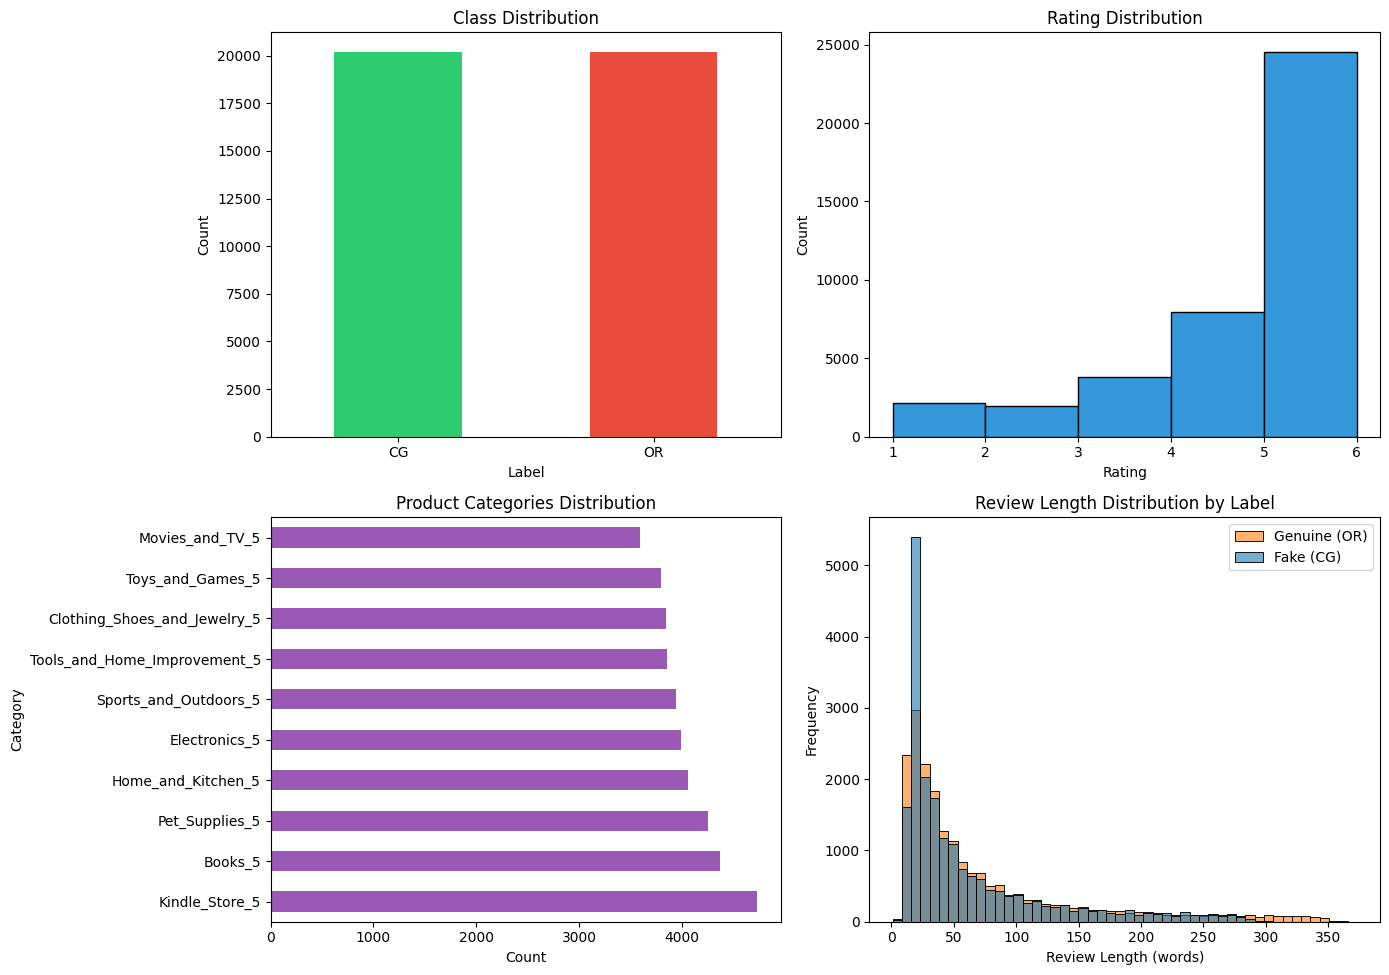

In [5]:
# ============================================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================
print("\n" + "=" * 65)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 65)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Class distribution
df['label'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Class Distribution')
axes[0,0].set_xlabel('Label')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# Rating distribution
df['rating'].hist(bins=[1,2,3,4,5,6], ax=axes[0,1], edgecolor='black', color='#3498db')
axes[0,1].set_title('Rating Distribution')
axes[0,1].set_xlabel('Rating')
axes[0,1].set_ylabel('Count')
axes[0,1].grid(False)

# Category distribution
df['category'].value_counts().plot(kind='barh', ax=axes[1,0], color='#9b59b6')
axes[1,0].set_title('Product Categories Distribution')
axes[1,0].set_xlabel('Count')
axes[1,0].set_ylabel('Category')

# Review length distribution by label
df['temp_length'] = df['text_'].apply(lambda x: len(str(x).split()))
sns.histplot(data=df, x='temp_length', hue='label', bins=50, alpha=0.6, ax=axes[1,1])
axes[1,1].set_title('Review Length Distribution by Label')
axes[1,1].set_xlabel('Review Length (words)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend(['Genuine (OR)', 'Fake (CG)'])
df.drop('temp_length', axis=1, inplace=True)

plt.suptitle('')
plt.tight_layout()
plt.show()

3. EXTRACT METADATA FEATURES

In [6]:
# ============================================================================
# 3. EXTRACT METADATA FEATURES
# ============================================================================
print("\n" + "=" * 65)
print("EXTRACTING METADATA FEATURES")
print("=" * 65)

# Review length (word count)
df['review_length'] = df['text_'].apply(lambda x: len(str(x).split()))

# Uppercase ratio
df['uppercase_ratio'] = df['text_'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1e-5))

# Lexical diversity (unique words / total words)
df['lexical_diversity'] = df['text_'].apply(
    lambda x: len(set(str(x).lower().split())) / (len(str(x).split()) + 1e-5))

# Adjective frequency
def adj_frequency(text):
    tokens = word_tokenize(str(text).lower())
    tags = pos_tag(tokens)
    total = len(tokens)
    adjs = sum(1 for _, tag in tags if tag.startswith('JJ'))
    return adjs / (total + 1e-5)

print("  Computing adjective frequency...")
df['adj_frequency'] = df['text_'].apply(adj_frequency)

# Sentiment score (VADER)
print("  Computing sentiment scores...")
sia = SentimentIntensityAnalyzer()
df['sentiment_score'] = df['text_'].apply(
    lambda x: sia.polarity_scores(str(x))['compound'])

# Perplexity score (GPT-2)
print("\n  Loading GPT-2 model...")
gpt2_tok = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_model = GPT2LMHeadModel.from_pretrained('gpt2')
gpt2_model = gpt2_model.to(device)
gpt2_model.eval()

if device.type == 'cuda':
    gpt2_model = gpt2_model.half()

def compute_perplexity(text, max_len=512):
    try:
        enc = gpt2_tok(str(text), return_tensors='pt', truncation=True, max_length=max_len)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            loss = gpt2_model(**enc, labels=enc['input_ids']).loss
        perp = torch.exp(loss).item()
        return perp
    except:
        return 100.0

print("  Computing perplexity for all reviews...")
perplexities = []
for text in tqdm(df['text_'], desc="Perplexity"):
    perplexities.append(compute_perplexity(text))

# Store raw and capped versions
df['perplexity_raw'] = perplexities
cap_value = df['perplexity_raw'].quantile(0.99)
df['perplexity'] = df['perplexity_raw'].clip(upper=cap_value)
df['perplexity'].fillna(df['perplexity'].median(), inplace=True)

print(f"  ✅ Perplexity range (capped at 99th percentile): {df['perplexity'].min():.2f} - {df['perplexity'].max():.2f}")

# Clear GPU cache
torch.cuda.empty_cache()

# Display metadata features
print("\nMetadata features extracted:")
metadata_cols = ['review_length', 'uppercase_ratio', 'lexical_diversity', 
                 'adj_frequency', 'sentiment_score', 'perplexity']
print(df[metadata_cols].describe())

# Split by label
print("\nMetadata Statistics by Label:")
print("=" * 50)
print("\nFAKE (CG) Reviews:")
print(df[df['label']=='CG'][metadata_cols].describe())
print("\nGENUINE (OR) Reviews:")
print(df[df['label']=='OR'][metadata_cols].describe())


EXTRACTING METADATA FEATURES
  Computing adjective frequency...
  Computing sentiment scores...

  Loading GPT-2 model...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 4551.50it/s]


  Computing perplexity for all reviews...


Perplexity: 100%|██████████| 40432/40432 [09:45<00:00, 69.06it/s]


  ✅ Perplexity range (capped at 99th percentile): 1.22 - 387.27

Metadata features extracted:
       review_length  uppercase_ratio  lexical_diversity  adj_frequency  \
count   40432.000000     40432.000000       40432.000000   40432.000000   
mean       67.465423         0.030719           0.787632       0.100510   
std        69.581333         0.047669           0.154617       0.050363   
min         1.000000         0.000000           0.029412       0.000000   
25%        21.000000         0.018868           0.687500       0.068493   
50%        39.000000         0.024566           0.810236       0.095238   
75%        85.000000         0.032911           0.909090       0.125000   
max       373.000000         0.837398           1.000000       0.977612   

       sentiment_score    perplexity  
count     40432.000000  40432.000000  
mean          0.617103     50.124583  
std           0.462667     59.705335  
min          -0.999700      1.220590  
25%           0.458800     16.26499

4. PERPLEXITY STATISTICAL ANALYSIS


PERPLEXITY DISTRIBUTION ANALYSIS (CG vs OR)

Perplexity Statistics:
--------------------------------------------------
  Fake (CG) - Mean:   24.79
  Fake (CG) - Median: 16.48
  Fake (CG) - Std Dev: 25.68
  Fake (CG) - Min:    1.22
  Fake (CG) - Max:    387.27

  Genuine (OR) - Mean:   75.46
  Genuine (OR) - Median: 50.04
  Genuine (OR) - Std Dev: 72.02
  Genuine (OR) - Min:    3.86
  Genuine (OR) - Max:    387.27


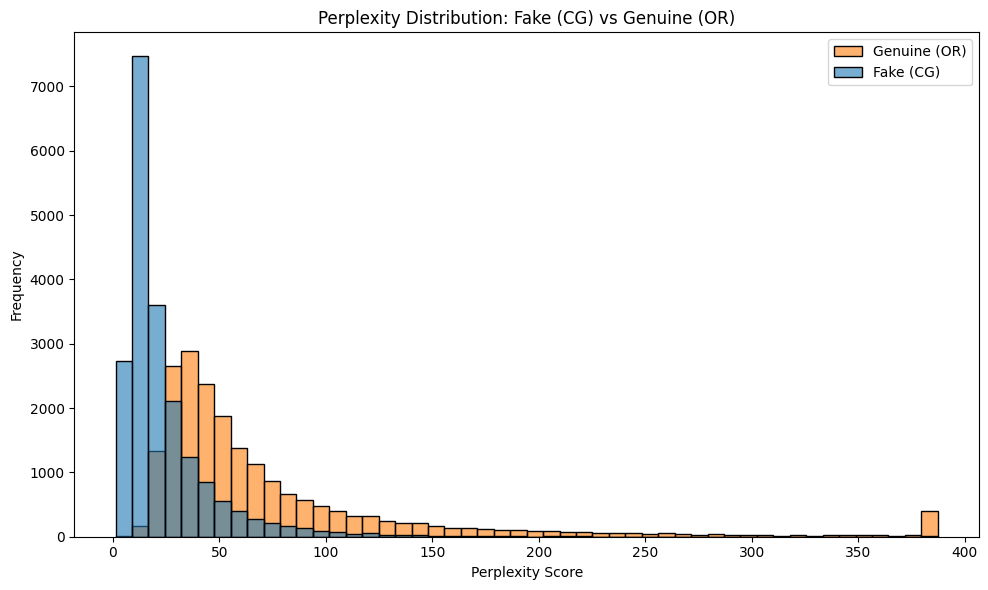

In [7]:
# ============================================================================
# 4. PERPLEXITY STATISTICAL ANALYSIS (Fake vs Genuine)
# ============================================================================
print("\n" + "=" * 65)
print("PERPLEXITY DISTRIBUTION ANALYSIS (CG vs OR)")
print("=" * 65)

# Calculate statistics for Fake (CG) and Genuine (OR)
fake_perplexity = df[df['label'] == 'CG']['perplexity']
genuine_perplexity = df[df['label'] == 'OR']['perplexity']

# Statistical summary
print("\nPerplexity Statistics:")
print("-" * 50)
print(f"  Fake (CG) - Mean:   {fake_perplexity.mean():.2f}")
print(f"  Fake (CG) - Median: {fake_perplexity.median():.2f}")
print(f"  Fake (CG) - Std Dev: {fake_perplexity.std():.2f}")
print(f"  Fake (CG) - Min:    {fake_perplexity.min():.2f}")
print(f"  Fake (CG) - Max:    {fake_perplexity.max():.2f}")

print(f"\n  Genuine (OR) - Mean:   {genuine_perplexity.mean():.2f}")
print(f"  Genuine (OR) - Median: {genuine_perplexity.median():.2f}")
print(f"  Genuine (OR) - Std Dev: {genuine_perplexity.std():.2f}")
print(f"  Genuine (OR) - Min:    {genuine_perplexity.min():.2f}")
print(f"  Genuine (OR) - Max:    {genuine_perplexity.max():.2f}")

# Visualization
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='perplexity', hue='label', bins=50, alpha=0.6)
plt.title('Perplexity Distribution: Fake (CG) vs Genuine (OR)', fontsize=12)
plt.xlabel('Perplexity Score')
plt.ylabel('Frequency')
plt.legend(['Genuine (OR)', 'Fake (CG)'])
plt.tight_layout()
plt.show()

5. TEXT PREPROCESSING 

In [8]:
# ============================================================================
# 5. TEXT PREPROCESSING
# ============================================================================
print("\n" + "=" * 65)
print("TEXT PREPROCESSING")
print("=" * 65)

# Select a sample review
random_idx = 1  
sample_review = df['text_'].iloc[random_idx]

print(f"\nOriginal Review:")
print("-" * 50)
print(sample_review)
print("-" * 50)

print("\nPreprocessing Steps:")
print("-" * 50)

# Lowercase
step1 = sample_review.lower()
print(f"\n1. Lowercase:\n   {step1}")

# Remove punctuation and digits
step2 = re.sub(r'[^a-z\s]', '', step1)
print(f"\n2. Remove punctuation & digits:\n   {step2}")

# Tokenization
step3 = word_tokenize(step2)
print(f"\n3. Tokenization:\n   {step3}")

# Remove stopwords
stop_words = set(stopwords.words('english'))
step4 = [word for word in step3 if word not in stop_words]
print(f"\n4. Remove stopwords:\n   {step4}")

# Lemmatization
lemmatizer = WordNetLemmatizer()
step5 = [lemmatizer.lemmatize(word) for word in step4]
print(f"\n5. Lemmatization:\n   {step5}")

# Final cleaned text
step6 = ' '.join(step5)
print(f"\n6. Final Cleaned Text:\n   {step6}")

# Apply preprocessing to entire dataset
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

print("\nApplying preprocessing to dataset...")
df['clean_text'] = df['text_'].apply(preprocess_text)

print("\n✅ Text preprocessing complete")

df[['text_', 'clean_text']].head()


TEXT PREPROCESSING

Original Review:
--------------------------------------------------
love it, a great upgrade from the original.  I've had mine for a couple of years
--------------------------------------------------

Preprocessing Steps:
--------------------------------------------------

1. Lowercase:
   love it, a great upgrade from the original.  i've had mine for a couple of years

2. Remove punctuation & digits:
   love it a great upgrade from the original  ive had mine for a couple of years

3. Tokenization:
   ['love', 'it', 'a', 'great', 'upgrade', 'from', 'the', 'original', 'ive', 'had', 'mine', 'for', 'a', 'couple', 'of', 'years']

4. Remove stopwords:
   ['love', 'great', 'upgrade', 'original', 'ive', 'mine', 'couple', 'years']

5. Lemmatization:
   ['love', 'great', 'upgrade', 'original', 'ive', 'mine', 'couple', 'year']

6. Final Cleaned Text:
   love great upgrade original ive mine couple year

Applying preprocessing to dataset...

✅ Text preprocessing complete


,text_,clean_text
0,"Love this! Well made, sturdy, and very comfor...",love well made sturdy comfortable love itvery ...
1,"love it, a great upgrade from the original. I...",love great upgrade original ive mine couple year
2,This pillow saved my back. I love the look and...,pillow saved back love look feel pillow
3,"Missing information on how to use it, but it i...",missing information use great product price
4,Very nice set. Good quality. We have had the s...,nice set good quality set two month


6. TRAIN/TEST SPLIT (80:20)

In [9]:
# ============================================================================
# 6. TRAIN/TEST SPLIT (80:20)
# ============================================================================
print("\n" + "=" * 65)
print("TRAIN/TEST SPLIT (80:20)")
print("=" * 65)

# Encode CG/Fake as the positive class
label_mapping = {'OR': 0, 'CG': 1}
df['label_enc'] = df['label'].map(label_mapping)

if df['label_enc'].isna().any():
    unknown_labels = df.loc[df['label_enc'].isna(), 'label'].unique()
    raise ValueError(f'Unknown labels found: {unknown_labels}')
df['label_enc'] = df['label_enc'].astype(int)

# Label decoder for the Streamlit app
le = LabelEncoder()
le.classes_ = np.array(['OR', 'CG'], dtype=object)

# Verify label mapping
assert label_mapping['CG'] == 1 and label_mapping['OR'] == 0
assert le.inverse_transform([0, 1]).tolist() == ['OR', 'CG']
print('Label mapping confirmed: OR/Genuine = 0, CG/Fake = 1 (positive class)')

# Split data
y = df['label_enc']
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('label_enc', axis=1), y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)} ({len(X_train)/len(df)*100:.0f}%)")
print(f"Test samples: {len(X_test)} ({len(X_test)/len(df)*100:.0f}%)")

# Export CSV files
X_test[['text_', 'category', 'rating', 'label']].to_csv('test_set.csv', index=False)
X_train[['text_', 'category', 'rating', 'label']].to_csv('train_set.csv', index=False)
print("\n✅ Saved train_set.csv and test_set.csv")


TRAIN/TEST SPLIT (80:20)
Label mapping confirmed: OR/Genuine = 0, CG/Fake = 1 (positive class)
Training samples: 32345 (80%)
Test samples: 8087 (20%)

✅ Saved train_set.csv and test_set.csv


7. FEATURE ENGINEERING

In [10]:
# ============================================================================
# 7. FEATURE ENGINEERING
# ============================================================================
print("\n" + "=" * 65)
print("FEATURE ENGINEERING")
print("=" * 65)

# TF-IDF for text
print("\nExtracting TF-IDF features...")
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train['clean_text'])
X_test_tfidf = tfidf.transform(X_test['clean_text'])
print(f"    Text features: {X_train_tfidf.shape[1]:,}")

# One-hot encoding for category
print("\nEncoding categories...")
ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
X_train_cat = ohe.fit_transform(X_train[['category']])
X_test_cat = ohe.transform(X_test[['category']])
print(f"    Category features: {X_train_cat.shape[1]}")

# Rating normalization
print("\nNormalizing ratings...")
rating_scaler = MinMaxScaler()
X_train_rating = csr_matrix(rating_scaler.fit_transform(X_train[['rating']]))
X_test_rating = csr_matrix(rating_scaler.transform(X_test[['rating']]))
print(f"    Rating normalized to range [0, 1]")

# Rating deviation from category average
category_avg = X_train.groupby('category')['rating'].mean().to_dict()
X_train['rating_deviation'] = X_train.apply(
    lambda row: row['rating'] - category_avg.get(row['category'], 3), axis=1)
X_test['rating_deviation'] = X_test.apply(
    lambda row: row['rating'] - category_avg.get(row['category'], 3), axis=1)
print(f"    Rating deviation range: [{X_train['rating_deviation'].min():.2f}, {X_train['rating_deviation'].max():.2f}]")

# Metadata features
print("\nScaling metadata features...")
meta_features = ['review_length', 'uppercase_ratio', 'lexical_diversity',
                 'adj_frequency', 'sentiment_score', 'perplexity', 'rating_deviation']

meta_scaler = MinMaxScaler()
X_train_meta = csr_matrix(meta_scaler.fit_transform(X_train[meta_features]))
X_test_meta = csr_matrix(meta_scaler.transform(X_test[meta_features]))
print(f"    Metadata features: {len(meta_features)}")

# Build final feature sets
X_train_text = X_train_tfidf
X_test_text = X_test_tfidf

X_train_hybrid = hstack([X_train_tfidf, X_train_cat, X_train_rating, X_train_meta])
X_test_hybrid = hstack([X_test_tfidf, X_test_cat, X_test_rating, X_test_meta])

print(f"\nFeature sets ready:")
print(f"   Text-only training shape:  {X_train_text.shape}")
print(f"   Text-only test shape:      {X_test_text.shape}")
print(f"   Hybrid training shape:     {X_train_hybrid.shape}")
print(f"   Hybrid test shape:         {X_test_hybrid.shape}")

print(f"\nFEATURE BREAKDOWN:")
print(f"   TF-IDF text features:    {X_train_tfidf.shape[1]:,}")
print(f"   Category features:       {X_train_cat.shape[1]}")
print(f"   Rating (normalized):     {X_train_rating.shape[1]}")
print(f"   Metadata features:       {len(meta_features)}")
print(f"   ─────────────────────────────────")
print(f"   TOTAL HYBRID FEATURES:   {X_train_hybrid.shape[1]:,}")


FEATURE ENGINEERING

Extracting TF-IDF features...
    Text features: 15,000

Encoding categories...
    Category features: 10

Normalizing ratings...
    Rating normalized to range [0, 1]
    Rating deviation range: [-3.37, 0.84]

Scaling metadata features...
    Metadata features: 7

Feature sets ready:
   Text-only training shape:  (32345, 15000)
   Text-only test shape:      (8087, 15000)
   Hybrid training shape:     (32345, 15018)
   Hybrid test shape:         (8087, 15018)

FEATURE BREAKDOWN:
   TF-IDF text features:    15,000
   Category features:       10
   Rating (normalized):     1
   Metadata features:       7
   ─────────────────────────────────
   TOTAL HYBRID FEATURES:   15,018


8. FEATURE IMPORTANCE


FEATURE IMPORTANCE RANKING (Metadata Features)

Feature Importance Ranking:
          Feature  Importance
       perplexity    0.496754
    review_length    0.184366
lexical_diversity    0.102821
  uppercase_ratio    0.066580
  sentiment_score    0.059217
    adj_frequency    0.053742
 rating_deviation    0.036521


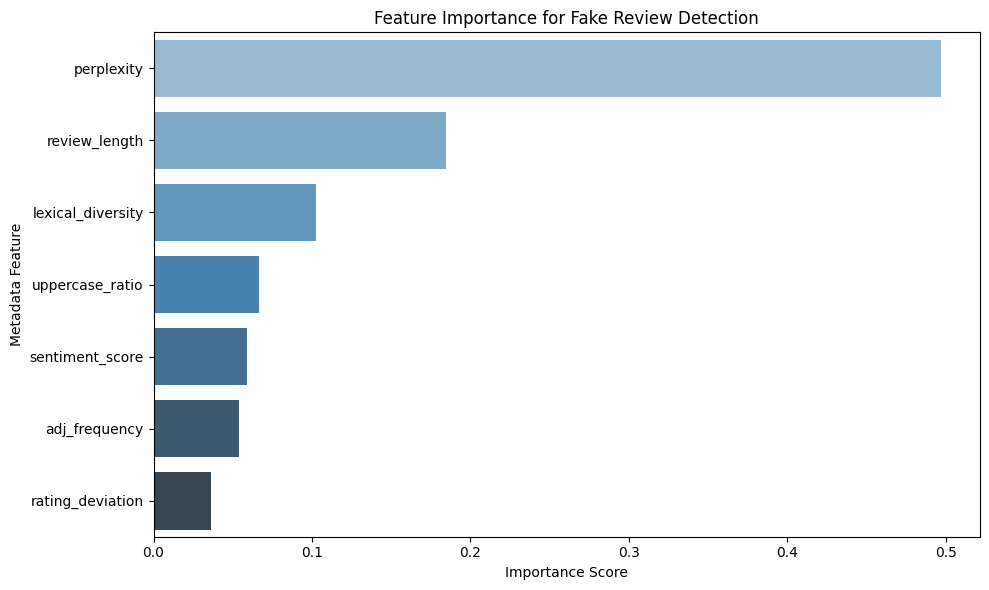


✅ Feature importance saved to 'feature_importance.csv'


In [11]:
# ============================================================================
# 8. FEATURE IMPORTANCE ANALYSIS (On Metadata Only)
# ============================================================================
print("\n" + "=" * 65)
print("FEATURE IMPORTANCE RANKING (Metadata Features)")
print("=" * 65)

# Train Random Forest using metadata features
from sklearn.ensemble import RandomForestClassifier

rf_feature_importance = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_feature_importance.fit(X_train_meta, y_train) 

# Calculate feature importance
importances = rf_feature_importance.feature_importances_
feature_names = meta_features  

# Sort features by importance
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Ranking:")
print(feature_importance_df.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='Blues_d')
plt.title('Feature Importance for Fake Review Detection')
plt.xlabel('Importance Score')
plt.ylabel('Metadata Feature')
plt.tight_layout()
plt.show()

# Save feature importance results
feature_importance_df.to_csv('feature_importance.csv', index=False)
print("\n✅ Feature importance saved to 'feature_importance.csv'")

9. EVALUATION FUNCTION

In [12]:
# ============================================================================
# 9. EVALUATION FUNCTION
# ============================================================================
print("\n" + "=" * 65)
print("MODEL EVALUATION FUNCTION")
print("=" * 65)

all_results = []

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, fit=True):
    if fit:
        model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted')
    rec = recall_score(y_te, y_pred, average='weighted')
    f1 = f1_score(y_te, y_pred, average='weighted')
    
    print(f"\n{name}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    
    all_results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4)
    })
    return model, y_pred

print("✅ Evaluation function ready")


MODEL EVALUATION FUNCTION
✅ Evaluation function ready


10. BASELINE MODELS

In [13]:
# ============================================================================
# 10. BASELINE MODELS (Text-only vs Hybrid)
# ============================================================================
print("\n" + "=" * 65)
print("BASELINE MODELS - TEXT-ONLY")
print("=" * 65)

baseline_models = {
    'SVM': LinearSVC(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

baseline_text_results = []
for name, model in baseline_models.items():
    trained_model, _ = evaluate_model(f"{name} [Text-Only]", model, 
                                       X_train_text, X_test_text, y_train, y_test)
    baseline_text_results.append(trained_model)

print("\n" + "=" * 65)
print("10. BASELINE MODELS - HYBRID")
print("=" * 65)

baseline_hybrid_results = []
for name, model in baseline_models.items():
    trained_model, _ = evaluate_model(f"{name} [Hybrid]", model,
                                       X_train_hybrid, X_test_hybrid, y_train, y_test)
    baseline_hybrid_results.append(trained_model)



BASELINE MODELS - TEXT-ONLY

SVM [Text-Only]
  Accuracy:  0.9106
  Precision: 0.9106
  Recall:    0.9106
  F1 Score:  0.9106

Random Forest [Text-Only]
  Accuracy:  0.8645
  Precision: 0.8647
  Recall:    0.8645
  F1 Score:  0.8645

Logistic Regression [Text-Only]
  Accuracy:  0.9019
  Precision: 0.9019
  Recall:    0.9019
  F1 Score:  0.9019

10. BASELINE MODELS - HYBRID

SVM [Hybrid]
  Accuracy:  0.9362
  Precision: 0.9363
  Recall:    0.9362
  F1 Score:  0.9362

Random Forest [Hybrid]
  Accuracy:  0.9392
  Precision: 0.9392
  Recall:    0.9392
  F1 Score:  0.9392

Logistic Regression [Hybrid]
  Accuracy:  0.9301
  Precision: 0.9302
  Recall:    0.9301
  F1 Score:  0.9301


11. BASELINE RESULTS TABLE


BASELINE RESULTS COMPARISON
                                 Accuracy  Precision  Recall  F1 Score
Model                                                                 
SVM [Text-Only]                    0.9106     0.9106  0.9106    0.9106
Random Forest [Text-Only]          0.8645     0.8647  0.8645    0.8645
Logistic Regression [Text-Only]    0.9019     0.9019  0.9019    0.9019
SVM [Hybrid]                       0.9362     0.9363  0.9362    0.9362
Random Forest [Hybrid]             0.9392     0.9392  0.9392    0.9392
Logistic Regression [Hybrid]       0.9301     0.9302  0.9301    0.9301


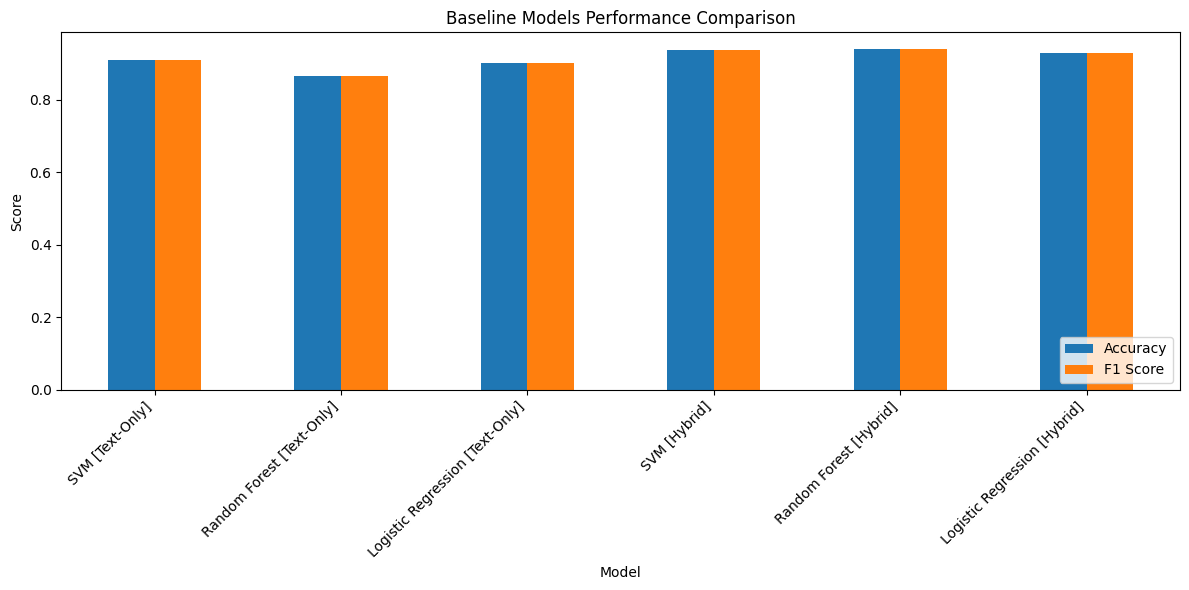

In [14]:
# ============================================================================
# 11. BASELINE RESULTS TABLE
# ============================================================================
print("\n" + "=" * 80)
print("BASELINE RESULTS COMPARISON")
print("=" * 80)

results_df = pd.DataFrame(all_results).set_index('Model')
print(results_df.to_string())

# Visual comparison
fig, ax = plt.subplots(figsize=(12, 6))
results_df[['Accuracy', 'F1 Score']].plot(kind='bar', ax=ax)
ax.set_title('Baseline Models Performance Comparison')
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.legend(loc='lower right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

12. HYPERPARAMETER TUNING

In [15]:
# ============================================================================
# 12. HYPERPARAMETER TUNING
# ============================================================================
print("\n" + "=" * 65)
print("HYPERPARAMETER TUNING")
print("=" * 65)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tuned_models = {}

# Tuning SVM
print("\nTuning SVM...")
grid_svm_text = GridSearchCV(
    LinearSVC(max_iter=5000, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 100], 'class_weight': [None, 'balanced']},
    cv=cv, scoring='f1_weighted', n_jobs=-1
)
grid_svm_text.fit(X_train_text, y_train)
tuned_models['SVM_Text'] = grid_svm_text.best_estimator_
print(f"    SVM Text-only best params: {grid_svm_text.best_params_}")
print(f"    Best CV score: {grid_svm_text.best_score_:.4f}")

grid_svm_hybrid = GridSearchCV(
    LinearSVC(max_iter=5000, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 100], 'class_weight': [None, 'balanced']},
    cv=cv, scoring='f1_weighted', n_jobs=-1
)

grid_svm_hybrid.fit(X_train_hybrid, y_train)
tuned_models['SVM_Hybrid'] = grid_svm_hybrid.best_estimator_
print(f"    SVM Hybrid best params: {grid_svm_hybrid.best_params_}")
print(f"    Best CV score: {grid_svm_hybrid.best_score_:.4f}")

# Tuning Random Forest
print("\nTuning Random Forest...")
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'class_weight': [None, 'balanced']
}

grid_rf_text = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, cv=cv, scoring='f1_weighted', n_jobs=-1
)
grid_rf_text.fit(X_train_text, y_train)
tuned_models['RF_Text'] = grid_rf_text.best_estimator_
print(f"    RF Text-only best params: {grid_rf_text.best_params_}")
print(f"    Best CV score: {grid_rf_text.best_score_:.4f}")

grid_rf_hybrid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, cv=cv, scoring='f1_weighted', n_jobs=-1
)
grid_rf_hybrid.fit(X_train_hybrid, y_train)
tuned_models['RF_Hybrid'] = grid_rf_hybrid.best_estimator_
print(f"    RF Hybrid best params: {grid_rf_hybrid.best_params_}")
print(f"    Best CV score: {grid_rf_hybrid.best_score_:.4f}")

# Tuning Logistic Regression
print("\nTuning Logistic Regression...")
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced']
}

grid_lr_text = GridSearchCV(
    LogisticRegression(max_iter=3000, random_state=42, n_jobs=-1),
    lr_params, cv=cv, scoring='f1_weighted', n_jobs=-1
)
grid_lr_text.fit(X_train_text, y_train)
tuned_models['LR_Text'] = grid_lr_text.best_estimator_
print(f"    LR Text-only best params: {grid_lr_text.best_params_}")
print(f"    Best CV score: {grid_lr_text.best_score_:.4f}")

grid_lr_hybrid = GridSearchCV(
    LogisticRegression(max_iter=3000, random_state=42, n_jobs=-1),
    lr_params, cv=cv, scoring='f1_weighted', n_jobs=-1
)
grid_lr_hybrid.fit(X_train_hybrid, y_train)
tuned_models['LR_Hybrid'] = grid_lr_hybrid.best_estimator_
print(f"    LR Hybrid best params: {grid_lr_hybrid.best_params_}")
print(f"    Best CV score: {grid_lr_hybrid.best_score_:.4f}")


HYPERPARAMETER TUNING

Tuning SVM...
    SVM Text-only best params: {'C': 1, 'class_weight': None}
    Best CV score: 0.9051
    SVM Hybrid best params: {'C': 1, 'class_weight': None}
    Best CV score: 0.9285

Tuning Random Forest...
    RF Text-only best params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
    Best CV score: 0.8610
    RF Hybrid best params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}
    Best CV score: 0.9351

Tuning Logistic Regression...
    LR Text-only best params: {'C': 10, 'class_weight': 'balanced', 'solver': 'lbfgs'}
    Best CV score: 0.9064
    LR Hybrid best params: {'C': 10, 'class_weight': 'balanced', 'solver': 'lbfgs'}
    Best CV score: 0.9300


13. TUNED MODELS PERFORMANCE

In [16]:
# ============================================================================
# 13. TUNED MODELS PERFORMANCE (On Test Set)
# ============================================================================
print("\n" + "=" * 65)
print("TUNED MODELS PERFORMANCE")
print("=" * 65)

tuned_test_results = []

for model_name, model in tuned_models.items():
    if 'Text' in model_name:
        X_test_use = X_test_text
        feature_type = "Text-Only"
    else:
        X_test_use = X_test_hybrid
        feature_type = "Hybrid"
    
    if 'SVM' in model_name:
        algo = "SVM"
    elif 'RF' in model_name:
        algo = "Random Forest"
    else:
        algo = "Logistic Regression"
    
    y_pred = model.predict(X_test_use)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"\n{algo} [{feature_type} | Tuned]")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    
    tuned_test_results.append({
        'Model': f"{algo} [{feature_type} Tuned]",
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4)
    })



TUNED MODELS PERFORMANCE

SVM [Text-Only | Tuned]
  Accuracy:  0.9106
  Precision: 0.9106
  Recall:    0.9106
  F1 Score:  0.9106

SVM [Hybrid | Tuned]
  Accuracy:  0.9362
  Precision: 0.9363
  Recall:    0.9362
  F1 Score:  0.9362

Random Forest [Text-Only | Tuned]
  Accuracy:  0.8662
  Precision: 0.8664
  Recall:    0.8662
  F1 Score:  0.8662

Random Forest [Hybrid | Tuned]
  Accuracy:  0.9427
  Precision: 0.9428
  Recall:    0.9427
  F1 Score:  0.9427

Logistic Regression [Text-Only | Tuned]
  Accuracy:  0.9106
  Precision: 0.9106
  Recall:    0.9106
  F1 Score:  0.9106

Logistic Regression [Hybrid | Tuned]
  Accuracy:  0.9357
  Precision: 0.9357
  Recall:    0.9357
  F1 Score:  0.9357


14. COMPARISON RESULTS


COMPARISON RESULTS

TABLE 1: BASELINE VS HYPERPARAMETER-TUNED MODELS


,Accuracy,Precision,Recall,F1 Score
Model,,,,
SVM [Text-Only],0.9106,0.9106,0.9106,0.9106
SVM [Text-Only Tuned],0.9106,0.9106,0.9106,0.9106
Random Forest [Text-Only],0.8645,0.8647,0.8645,0.8645
Random Forest [Text-Only Tuned],0.8662,0.8664,0.8662,0.8662
Logistic Regression [Text-Only],0.9019,0.9019,0.9019,0.9019
Logistic Regression [Text-Only Tuned],0.9106,0.9106,0.9106,0.9106
SVM [Hybrid],0.9362,0.9363,0.9362,0.9362
SVM [Hybrid Tuned],0.9362,0.9363,0.9362,0.9362
Random Forest [Hybrid],0.9392,0.9392,0.9392,0.9392



TABLE 2: TUNED TEXT-ONLY VS TUNED HYBRID MODELS


,Accuracy,Precision,Recall,F1 Score
Model,,,,
SVM [Text-Only Tuned],0.9106,0.9106,0.9106,0.9106
SVM [Hybrid Tuned],0.9362,0.9363,0.9362,0.9362
Random Forest [Text-Only Tuned],0.8662,0.8664,0.8662,0.8662
Random Forest [Hybrid Tuned],0.9427,0.9428,0.9427,0.9427
Logistic Regression [Text-Only Tuned],0.9106,0.9106,0.9106,0.9106
Logistic Regression [Hybrid Tuned],0.9357,0.9357,0.9357,0.9357



TABLE 3: TUNED HYBRID ALGORITHM COMPARISON


,Accuracy,Precision,Recall,F1 Score
Model,,,,
SVM [Hybrid Tuned],0.9362,0.9363,0.9362,0.9362
Random Forest [Hybrid Tuned],0.9427,0.9428,0.9427,0.9427
Logistic Regression [Hybrid Tuned],0.9357,0.9357,0.9357,0.9357



BEST MODEL: Random Forest [Hybrid Tuned]
F1 Score: 0.9427


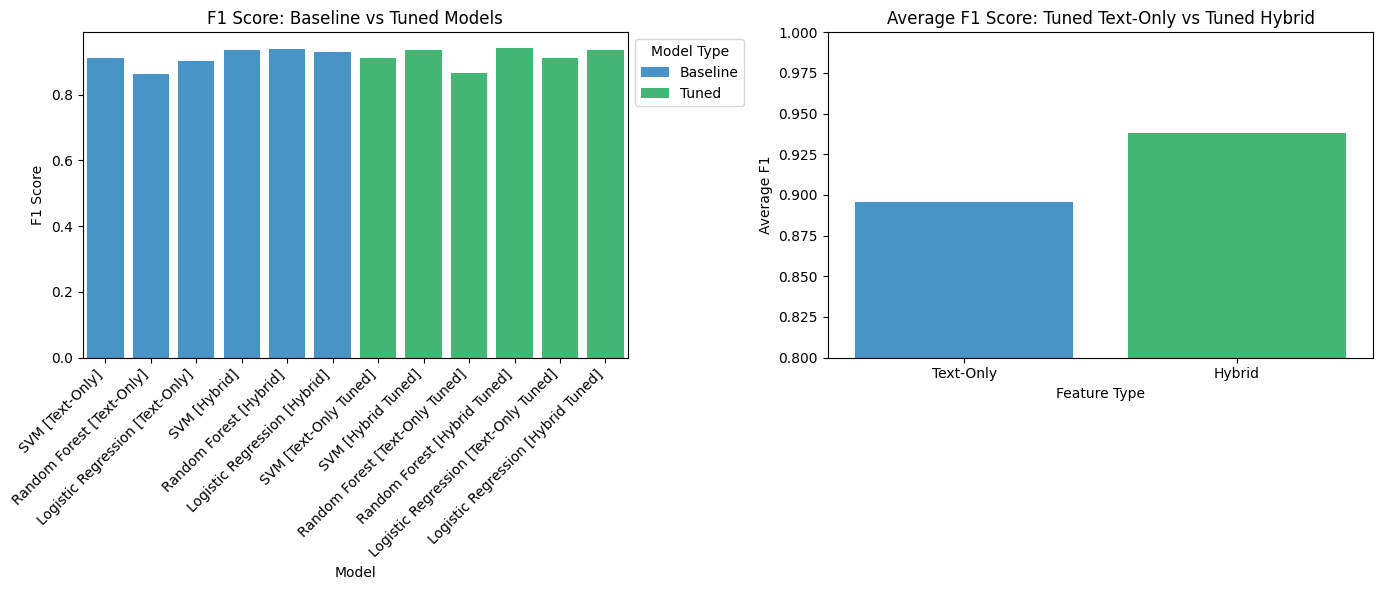

In [17]:
# ============================================================================
# 14. COMPARISON RESULTS TABLE
# ============================================================================
print("\n" + "=" * 80)
print("COMPARISON RESULTS")
print("=" * 80)

all_final_results = pd.DataFrame(all_results + tuned_test_results).set_index('Model')
comparison_columns = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Table 1: baseline and tuned models for both feature sets
baseline_tuned_names = [
    'SVM [Text-Only]', 'SVM [Text-Only Tuned]',
    'Random Forest [Text-Only]', 'Random Forest [Text-Only Tuned]',
    'Logistic Regression [Text-Only]', 'Logistic Regression [Text-Only Tuned]',
    'SVM [Hybrid]', 'SVM [Hybrid Tuned]',
    'Random Forest [Hybrid]', 'Random Forest [Hybrid Tuned]',
    'Logistic Regression [Hybrid]', 'Logistic Regression [Hybrid Tuned]'
]
baseline_tuned_table = all_final_results.loc[baseline_tuned_names, comparison_columns]
print('\nTABLE 1: BASELINE VS HYPERPARAMETER-TUNED MODELS')
display(baseline_tuned_table)

# Table 2: tuned text-only and tuned hybrid models
tuned_feature_names = [
    'SVM [Text-Only Tuned]', 'SVM [Hybrid Tuned]',
    'Random Forest [Text-Only Tuned]', 'Random Forest [Hybrid Tuned]',
    'Logistic Regression [Text-Only Tuned]', 'Logistic Regression [Hybrid Tuned]'
]
tuned_feature_table = all_final_results.loc[tuned_feature_names, comparison_columns]
print('\nTABLE 2: TUNED TEXT-ONLY VS TUNED HYBRID MODELS')
display(tuned_feature_table)

# Select the best tuned hybrid model
tuned_hybrid_names = [
    'SVM [Hybrid Tuned]',
    'Random Forest [Hybrid Tuned]',
    'Logistic Regression [Hybrid Tuned]'
]
tuned_hybrid_results = all_final_results.loc[tuned_hybrid_names]
tuned_hybrid_table = tuned_hybrid_results[comparison_columns]
print('\nTABLE 3: TUNED HYBRID ALGORITHM COMPARISON')
display(tuned_hybrid_table)
best_model_name = tuned_hybrid_results['F1 Score'].idxmax()
best_f1 = tuned_hybrid_results.loc[best_model_name, 'F1 Score']
print(f"\n{'='*80}")
print(f"BEST MODEL: {best_model_name}")
print(f"F1 Score: {best_f1:.4f}")
print(f"{'='*80}")

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Baseline and tuned F1-score comparison
baseline_vs_tuned = all_final_results[['Accuracy', 'F1 Score']].reset_index()
baseline_vs_tuned['Type'] = baseline_vs_tuned['Model'].apply(
    lambda x: 'Baseline' if 'Tuned' not in x else 'Tuned')
sns.barplot(data=baseline_vs_tuned, x='Model', y='F1 Score', hue='Type', 
            palette={'Baseline': '#3498db', 'Tuned': '#2ecc71'}, ax=axes[0])
axes[0].set_title('F1 Score: Baseline vs Tuned Models')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel('F1 Score')
axes[0].set_xlabel('Model')
axes[0].legend(title='Model Type', bbox_to_anchor=(1, 1), loc='upper left', frameon=True)

# Tuned text-only and hybrid comparison
tuned_only = all_final_results[all_final_results.index.str.contains('Tuned')]
text_only = tuned_only[tuned_only.index.str.contains('Text-Only')]
hybrid = tuned_only[tuned_only.index.str.contains('Hybrid')]
comparison = pd.DataFrame({
    'Feature Type': ['Text-Only', 'Hybrid'],
    'Average F1': [text_only['F1 Score'].mean(), hybrid['F1 Score'].mean()]
})
sns.barplot(data=comparison, x='Feature Type', y='Average F1', ax=axes[1], palette=['#3498db', '#2ecc71'])
axes[1].set_title('Average F1 Score: Tuned Text-Only vs Tuned Hybrid')
axes[1].set_ylim(0.8, 1.0)

plt.tight_layout()
plt.show()

15. BEST MODEL


BEST MODEL DETAILED EVALUATION

Confusion Matrix Interpretation (CG/Fake is the positive class):
  TP - Fake correctly predicted as fake: 3787
  TN - Genuine correctly predicted as genuine: 3837
  FP - Genuine wrongly predicted as fake: 207
  FN - Fake wrongly predicted as genuine: 256


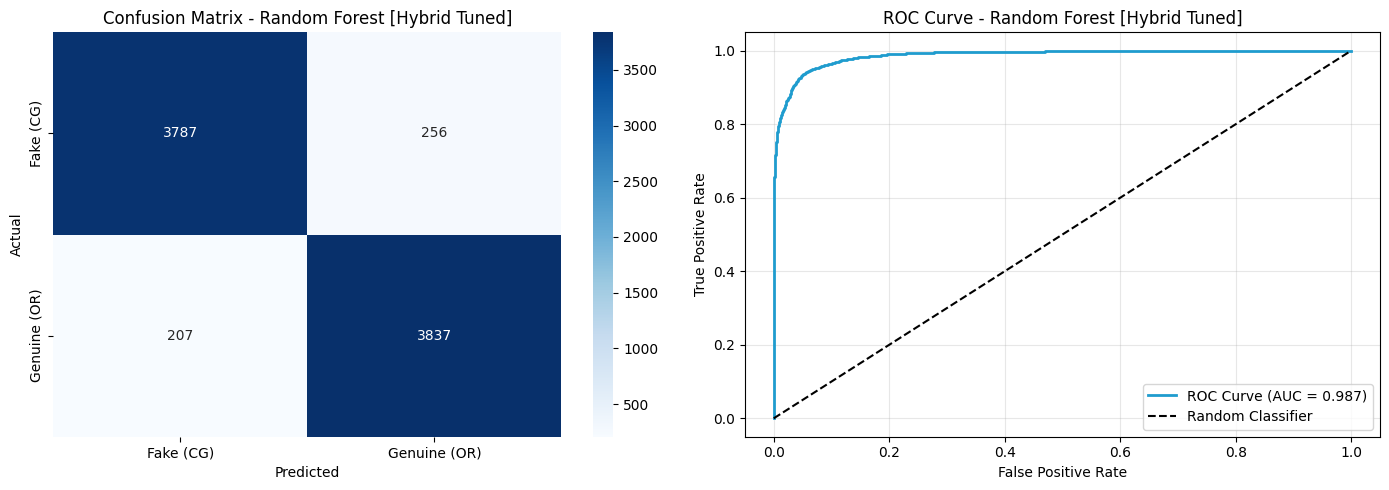


Classification Report:
              precision    recall  f1-score   support

Genuine (OR)       0.94      0.95      0.94      4044
   Fake (CG)       0.95      0.94      0.94      4043

    accuracy                           0.94      8087
   macro avg       0.94      0.94      0.94      8087
weighted avg       0.94      0.94      0.94      8087



In [18]:
# ============================================================================
# 15. BEST MODEL DETAILS (Confusion Matrix & ROC AUC)
# ============================================================================
print("\n" + "=" * 65)
print("BEST MODEL DETAILED EVALUATION")
print("=" * 65)

# Load the selected tuned hybrid model
deployment_model_keys = {
    'SVM [Hybrid Tuned]': 'SVM_Hybrid',
    'Random Forest [Hybrid Tuned]': 'RF_Hybrid',
    'Logistic Regression [Hybrid Tuned]': 'LR_Hybrid'
}
final_best_model = tuned_models[deployment_model_keys[best_model_name]]

# Use hybrid test features
X_test_final = X_test_hybrid

y_pred_best = final_best_model.predict(X_test_final)
y_pred_proba = final_best_model.predict_proba(X_test_final)[:, 1] if hasattr(final_best_model, 'predict_proba') else None

# Calculate confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_best, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Interpretation (CG/Fake is the positive class):")
print(f"  TP - Fake correctly predicted as fake: {tp}")
print(f"  TN - Genuine correctly predicted as genuine: {tn}")
print(f"  FP - Genuine wrongly predicted as fake: {fp}")
print(f"  FN - Fake wrongly predicted as genuine: {fn}")

# Display Fake (CG) first
cm_corrected = np.array([
    [cm[1][1], cm[1][0]],  # Row 1: TP, FN
    [cm[0][1], cm[0][0]]   # Row 0: FP, TN
])

sns.heatmap(cm_corrected, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Fake (CG)', 'Genuine (OR)'],
            yticklabels=['Fake (CG)', 'Genuine (OR)'])
axes[0].set_title(f'Confusion Matrix - {best_model_name}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Plot ROC curve
if y_pred_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})', color="#1f9cce", linewidth=2)
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve - {best_model_name}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Genuine (OR)', 'Fake (CG)']))

16. SAVE BEST MODEL

In [19]:
# ============================================================================
# 16. SAVE BEST MODEL
# ============================================================================
print("\n" + "=" * 65)
print("SAVING BEST MODEL")
print("=" * 65)

# Create model directory
os.makedirs('frd_model', exist_ok=True)

# Save model files
joblib.dump(final_best_model, 'frd_model/best_model.pkl')
joblib.dump(tfidf, 'frd_model/tfidf.pkl')
joblib.dump(ohe, 'frd_model/ohe.pkl')
joblib.dump(rating_scaler, 'frd_model/rating_scaler.pkl')
joblib.dump(meta_scaler, 'frd_model/meta_scaler.pkl')
joblib.dump(le, 'frd_model/label_encoder.pkl')
joblib.dump(category_avg, 'frd_model/category_avg_map.pkl')
joblib.dump(meta_features, 'frd_model/meta_features.pkl')

# Save dashboard metrics
os.makedirs('frd_model/metrics', exist_ok=True)

# Save comparison results
all_final_results.to_csv('frd_model/metrics/all_results.csv')
baseline_tuned_table.to_csv('frd_model/metrics/comparison_baseline_tuned.csv')
tuned_feature_table.to_csv('frd_model/metrics/comparison_tuned_text_hybrid.csv')
tuned_hybrid_table.to_csv('frd_model/metrics/comparison_tuned_hybrid_algorithms.csv')

# Save selected model details
best_model_info = pd.DataFrame([{
    'best_model_name': best_model_name,
    'best_f1_score': best_f1,
    'best_accuracy': all_final_results.loc[best_model_name, 'Accuracy'],
    'best_precision': all_final_results.loc[best_model_name, 'Precision'],
    'best_recall': all_final_results.loc[best_model_name, 'Recall']
}])
best_model_info.to_csv('frd_model/metrics/best_model_info.csv', index=False)

# Save evaluation results in [[TN, FP], [FN, TP]] order
cm_df = pd.DataFrame(cm, index=['Actual Genuine', 'Actual Fake'], 
                     columns=['Predicted Genuine', 'Predicted Fake'])
cm_df.to_csv('frd_model/metrics/confusion_matrix.csv')

if y_pred_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    roc_info = pd.DataFrame([{'auc_score': auc}])
    roc_info.to_csv('frd_model/metrics/roc_auc.csv', index=False)

    # Save ROC curve data
    roc_curve_df = pd.DataFrame({
        'fpr': fpr,
        'tpr': tpr
    })
    roc_curve_df.to_csv('frd_model/metrics/roc_curve.csv', index=False)

print("\n✅ Model and artifacts saved to 'frd_model/'")
print("\nSaved files:")
for f in sorted(os.listdir('frd_model')):
    print(f"  - {f}")

print("\n" + "=" * 65)
print("TRAINING COMPLETE!")
print("=" * 65)


SAVING BEST MODEL

✅ Model and artifacts saved to 'frd_model/'

Saved files:
  - best_model.pkl
  - category_avg_map.pkl
  - label_encoder.pkl
  - meta_features.pkl
  - meta_scaler.pkl
  - metrics
  - ohe.pkl
  - rating_scaler.pkl
  - tfidf.pkl

TRAINING COMPLETE!
